<a href="https://colab.research.google.com/github/statftn/Deep-Learning-Theory-and-Practice/blob/main/chapter05_fundamentals_of_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [1]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 23.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.32.0 which is incompatible.


In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Fundamentals of machine learning

### Generalization: The goal of machine learning

#### Underfitting and overfitting

##### Noisy training data

##### Ambiguous features

##### Rare features and spurious correlations

In [4]:
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()   # load mnist dataset
train_images = train_images.reshape((60000, 28 * 28))   # (60000, 28, 28) 형태의 3차원 배열에서 (샘플 수, 28 * 28) 형태의 2차원 배열로 변경
train_images = train_images.astype("float32") / 255   # data normalization: 0~255 -> 0~1

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
train_images.shape

(60000, 784)

In [6]:
np.random.random((len(train_images), 784))
# 행: MNIST 학습 이미지의 개수(leng(train_images): 60000개)
# 열: 28 * 28 = 784 (28 * 28 픽셀 이미지를 평탄화)
# random: 각 요소는 0.0 ~ 1.0 무작위 부동 소수점 숫자

array([[0.54248537, 0.80840851, 0.64679051, ..., 0.76214375, 0.48569814,
        0.69995445],
       [0.51645338, 0.52852668, 0.38521943, ..., 0.40277688, 0.94958672,
        0.63713342],
       [0.25073392, 0.6292087 , 0.24403227, ..., 0.73817988, 0.90323721,
        0.85227397],
       ...,
       [0.97284046, 0.42274082, 0.77730481, ..., 0.48202645, 0.51396797,
        0.76941283],
       [0.53088977, 0.00656245, 0.61108983, ..., 0.81929527, 0.78039839,
        0.92611272],
       [0.90380831, 0.70323926, 0.42505146, ..., 0.04227019, 0.62804142,
        0.42619017]])

In [7]:
np.random.random((len(train_images), 784)).shape

(60000, 784)

In [8]:
train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)   # 기존 데이터(784차원)에 백색 잡음 784차원을 연결하여 새로운 훈련 세트 만들기
# no relationship with labels
train_images_with_noise_channels.shape

(60000, 1568)

In [9]:
train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)   # 기존 데이터(784차원)에 모두 0인 784차원을 연결하여 새로운 훈련 세트 만들기
# 의미 없는 특성의 연결은 데이터 기존 정보에 전혀 영향을 미치지 않는다
train_images_with_zeros_channels.shape

(60000, 1568)

In [10]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(10, activation="softmax"),   # labels: 0~9
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)   # train with noisy channel dataset

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)   # train with zero channel dataset

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8697 - loss: 0.4293 - val_accuracy: 0.9243 - val_loss: 0.2586
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9332 - loss: 0.2267 - val_accuracy: 0.9271 - val_loss: 0.2391
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9547 - loss: 0.1541 - val_accuracy: 0.9455 - val_loss: 0.1774
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9685 - loss: 0.1064 - val_accuracy: 0.9563 - val_loss: 0.1484
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9769 - loss: 0.0790 - val_accuracy: 0.9539 - val_loss: 0.1583
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9849 - loss: 0.0556 - val_accuracy: 0.9588 - val_loss: 0.1424
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9895 - loss: 0.0392 - val_accuracy: 0.9614 - val_loss: 0.1392
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9929 - loss: 0.0267 - val_accuracy: 0.

In [11]:
history_noise.history

{'accuracy': [0.8696874976158142,
  0.9332291483879089,
  0.9546666741371155,
  0.968500018119812,
  0.976854145526886,
  0.984874963760376,
  0.9894999861717224,
  0.9929166436195374,
  0.9960625171661377,
  0.9973958134651184],
 'loss': [0.42927098274230957,
  0.22673825919628143,
  0.15411782264709473,
  0.1063685491681099,
  0.07899517565965652,
  0.05556657165288925,
  0.03918648511171341,
  0.026702092960476875,
  0.01804870180785656,
  0.013077698647975922],
 'val_accuracy': [0.9242500066757202,
  0.9270833134651184,
  0.9455000162124634,
  0.956250011920929,
  0.9539166688919067,
  0.9587500095367432,
  0.9614166617393494,
  0.9580000042915344,
  0.9629999995231628,
  0.9634999632835388],
 'val_loss': [0.25859534740448,
  0.23905827105045319,
  0.1774260699748993,
  0.14839185774326324,
  0.15832467377185822,
  0.14236201345920563,
  0.1391514539718628,
  0.1591634452342987,
  0.13531780242919922,
  0.13601262867450714]}

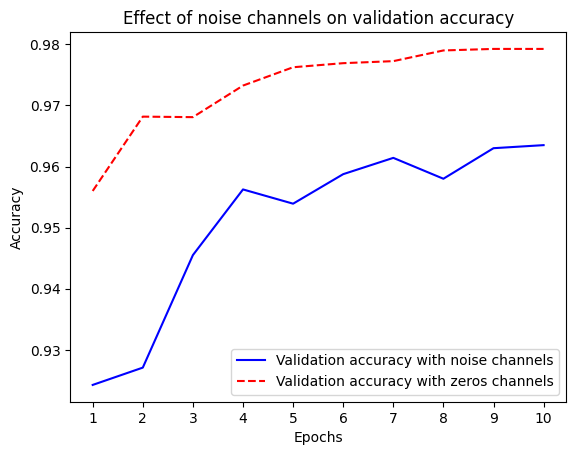

In [12]:
import matplotlib.pyplot as plt

val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(
    epochs,
    val_acc_noise,
    "b-",
    label="Validation accuracy with noise channels",
)
plt.plot(
    epochs,
    val_acc_zeros,
    "r--",
    label="Validation accuracy with zeros channels",
)
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()
# 백색 잡음과 0을 추가한 MNIST데이터로 훈련한 모델의 검증 정확도 비교
# 가짜 상관관계의 잡음이 섞인 데이터에서 훈련된 모델의 검증 정확도가 1%포인트 정도 낮다 (잡음을 더 많이 섞을수록 정확도는 더 감소)
# 잡음 특성은 필연적으로 과대적합 유발 -> 특성 선택을 통해 모델에 유익한 특성만 사용하여 해결
# 특성 선택의 일반적인 방법은 각 특성에 대해 유용성 점수 계산
# (특성과 레이블 사이에 상호 의존 정보처럼 작업에 대해 특성이 얼마나 유익한지 측정하여 임계 값을 넘긴 특성만 사용)

#### The nature of generalization in deep learning

In [13]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)   # correlation is broken
# MNIST 레이블의 순서를 랜덤하게 섞기 -> 입력과 레이블 사이에 관계 없어짐

# 랜덤하게 레이블의 순서를 섞은 후 모델 훈련 -> 입력과 레이블 사이에 아무런 관계가 없지만 훈련 손실 감소
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    random_train_labels,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
)
# 가능한 일반화가 없기 때문에 검증 손실은 시간이 지남에 따라 향상되지 않는다
# 레이블을 뒤섞을 경우 모델을 잘 훈련하더라도 검증 정확도는 0~9 숫자를 랜덤 섞을 경우 확률인 10%에 멈춘다

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1046 - loss: 2.3161 - val_accuracy: 0.1065 - val_loss: 2.3066
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1164 - loss: 2.2990 - val_accuracy: 0.1052 - val_loss: 2.3094
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1288 - loss: 2.2906 - val_accuracy: 0.1038 - val_loss: 2.3156
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1393 - loss: 2.2792 - val_accuracy: 0.0990 - val_loss: 2.3247
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1503 - loss: 2.2644 - val_accuracy: 0.1071 - val_loss: 2.3342
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1666 - loss: 2.2446 - val_accuracy: 0.1022 - val_loss: 2.3424
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1797 - loss: 2.2218 - val_accuracy: 0.1033 - val_loss: 2.3715
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1956 - loss: 2.1963 - val_accu

Some questions

In [14]:
# From Training the same model on MNIST data with noise channels or all zero channels
# Add validation accuracy of original data for mnist data

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = get_model()
history_ori = model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9120 - loss: 0.3048 - val_accuracy: 0.9548 - val_loss: 0.1560
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9648 - loss: 0.1236 - val_accuracy: 0.9674 - val_loss: 0.1107
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9763 - loss: 0.0818 - val_accuracy: 0.9721 - val_loss: 0.0915
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9835 - loss: 0.0571 - val_accuracy: 0.9738 - val_loss: 0.0833
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9886 - loss: 0.0419 - val_accuracy: 0.9760 - val_loss: 0.0787
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9914 - loss: 0.0316 - val_accuracy: 0.9782 - val_loss: 0.0732
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9934 - loss: 0.0241 - val_accuracy: 0.9767 - val_loss: 0.0762
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9952 - loss: 0.0186 - val_accuracy: 0.

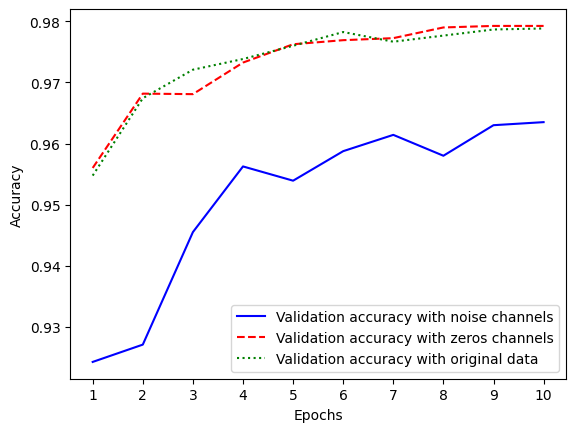

In [15]:
val_acc_ori = history_ori.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(
    epochs,
    val_acc_noise,
    "b-",
    label="Validation accuracy with noise channels",
)
plt.plot(
    epochs,
    val_acc_zeros,
    "r--",
    label="Validation accuracy with zeros channels",
)
plt.plot(
    epochs,
    val_acc_ori,
    "g:",
    label="Validation accuracy with original data",
)
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()
# 시험에는 ploting관련 출제 X
# model관련 설명만!!

In [16]:
# Fitting a MNIST model with randomly shuffled labels.
# Visualize training accuracy and validation accuracy.

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_shuffle = model.fit(
    train_images,
    random_train_labels,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1061 - loss: 2.3140 - val_accuracy: 0.1016 - val_loss: 2.3069
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1180 - loss: 2.2984 - val_accuracy: 0.1057 - val_loss: 2.3109
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1271 - loss: 2.2895 - val_accuracy: 0.1059 - val_loss: 2.3170
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1403 - loss: 2.2779 - val_accuracy: 0.1037 - val_loss: 2.3235
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1541 - loss: 2.2611 - val_accuracy: 0.0992 - val_loss: 2.3364
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1664 - loss: 2.2425 - val_accuracy: 0.1013 - val_loss: 2.3467
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1838 - loss: 2.2194 - val_accuracy: 0.1059 - val_loss: 2.3630
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1989 - loss: 2.1927 - val_accu

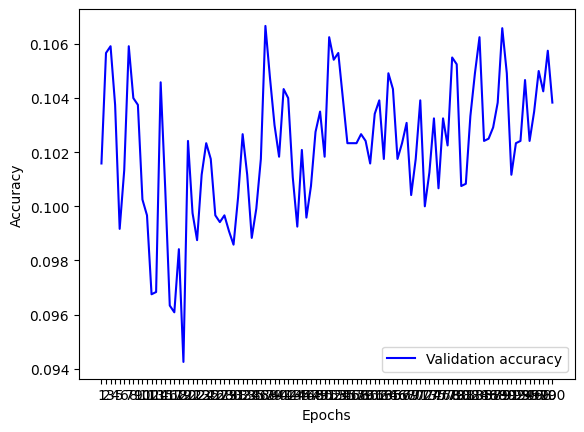

In [17]:
val_acc_shuffle = history_shuffle.history["val_accuracy"]
epochs = range(1, 101)
plt.plot(epochs, val_acc_shuffle, "b-", label="Validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

##### The manifold hypothesis

##### Interpolation as a source of generalization

##### Why deep learning works

##### Training data is paramount

### Evaluating machine-learning models

#### Training, validation, and test sets

##### Simple hold-out validation

In [ ]:
num_validation_samples = 10000
np.random.shuffle(data)   # 데이터를 섞는 것이 일반적으로 좋다
validation_data = data[:num_validation_samples]   # 검증 세트
training_data = data[num_validation_samples:]   # 훈련 세트
model = get_model()
model.train(training_data)   # 훈련 세트로 모델 훈련
validation_score = model.evaluate(validation_data)   # 검증 세트로 평가
# 모델을 튜닝, 훈련, 평가하는 과정을 반복
model = get_model()
model.fit(np.concatenate([training_data, validation_data]))   # 하이퍼파라미터 튜닝이 끝나면 테스트 데이터를 제외한 모든 데이터를 사용하여 모델을 다시 훈련
test_score = model.evaluate(test_data)

##### K-fold validation

In [ ]:
k = 3
num_validation_samples = len(data) // k
np.random.shuffle(data)
validation_scores = []
for fold in range(k):
    validation_data = data[num_validation_samples * fold : num_validation_samples * (fold + 1)]   # 검증 데이터 부분을 선택
    training_data = data[:num_validation_samples * fold] + data[num_validation_samples * (fold + 1) :]   # 나머지 데이터를 훈련 데이터로 사용
    model = get_model()
    model.fit(training_data)
    validation_score = model.evaluate(validation_data)
    validation_scores.append(validation_score)
validation_score = np.average(validation_scores)   # 검증 점수: k개의 폴드 검증 점수 평균
model = get_model()
model.fit(data)
test_score = model.evaluate(test_data)

##### Iterated K-fold validation with shuffling

#### Beating a common-sense baseline

#### Things to keep in mind about model evaluation

### Improving model fit

#### Tuning key gradient descent parameters

In [ ]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1.0),   # 부적절하게 큰 학습률인 1.0으로 학습 (learning rate: 디폴트 값 사용해도 괜찮고 데이터에 따라 직접 설정해도 좋음)
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)
# 높은 학습률로 훈련 -> 20~40% 정도의 훈련 정확도와 검증 정확도에 빠르게 도달하지만 이를 넘어서지 못한다

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1218 - loss: 14.1221 - val_accuracy: 0.0989 - val_loss: 14.5237
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0970 - loss: 14.5550 - val_accuracy: 0.0989 - val_loss: 14.5237
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0970 - loss: 14.5550 - val_accuracy: 0.0989 - val_loss: 14.5237
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0970 - loss: 14.5550 - val_accuracy: 0.0989 - val_loss: 14.5237
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0970 - loss: 14.5550 - val_accuracy: 0.0989 - val_loss: 14.5237
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0970 - loss: 14.5550 - val_accuracy: 0.0989 - val_loss: 14.5237
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0970 - loss: 14.5550 - val_accuracy: 0.0989 - val_loss: 14.5237
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0970 - loss: 14.5550 - v

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-2),   # 앞에서보다 조금 더 합리적인 값인 1e-2로 학습률을 낮추어 학습
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)
# 너무 높은 학습률은 최적적합을 크게 뛰어넘는 업데이트가 일어날 수 있다
# 너무 낮은 학습률은 훈련을 느리게 만들어 멈추어 있는 것처럼 보일 수 있다
# 배치 크기를 늘리면 유익하고 잡음이 적은 (분산이 낮은) 그레이디언트가 만들어진다

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9082 - loss: 0.3993 - val_accuracy: 0.9607 - val_loss: 0.1300
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9647 - loss: 0.1271 - val_accuracy: 0.9567 - val_loss: 0.1714
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9737 - loss: 0.1024 - val_accuracy: 0.9714 - val_loss: 0.1191
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9803 - loss: 0.0780 - val_accuracy: 0.9682 - val_loss: 0.1552
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9827 - loss: 0.0737 - val_accuracy: 0.9718 - val_loss: 0.1648
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9851 - loss: 0.0619 - val_accuracy: 0.9688 - val_loss: 0.1850
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9873 - loss: 0.0590 - val_accuracy: 0.9734 - val_loss: 0.1787
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9893 - loss: 0.0467 - val_accuracy: 0.

#### Using better architecture priors

#### Increasing model capacity

In [ ]:
model = keras.Sequential([layers.Dense(10, activation="softmax")])
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_small_model = model.fit(
    train_images, train_labels, epochs=20, batch_size=128, validation_split=0.2
)
# MNIST 데이터를 사용한 간단한 로지스틱 회귀(분류) 모델
# validation loss가 정점에 도달해서 역전되지 않고 (과대적합되지 못하고) 멈추어 있거나 매우 느리게 좋아진다

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8329 - loss: 0.6803 - val_accuracy: 0.9027 - val_loss: 0.3600
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9021 - loss: 0.3545 - val_accuracy: 0.9142 - val_loss: 0.3113
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9123 - loss: 0.3185 - val_accuracy: 0.9193 - val_loss: 0.2953
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9155 - loss: 0.3021 - val_accuracy: 0.9212 - val_loss: 0.2837
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9188 - loss: 0.2924 - val_accuracy: 0.9227 - val_loss: 0.2784
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9208 - loss: 0.2856 - val_accuracy: 0.9230 - val_loss: 0.2770
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9220 - loss: 0.2807 - val_accuracy: 0.9263 - val_loss: 0.2706
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9235 - loss: 0.2764 - val_accuracy: 0.

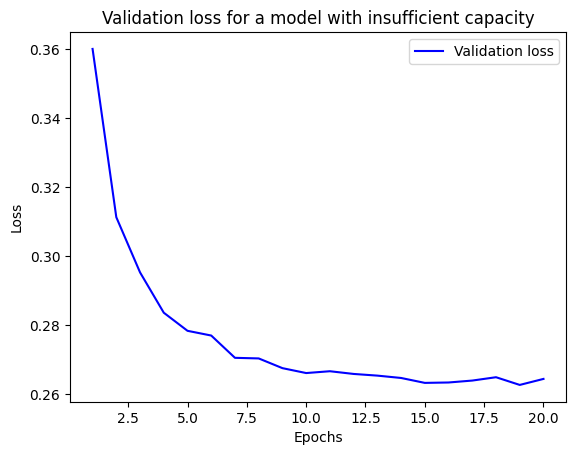

In [ ]:
import matplotlib.pyplot as plt

val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with insufficient capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# 과대적합할 수 없는 것처럼 보인다면 모델의 표현 능력이 부족한 것 -> 용량이 더 큰 모델(더 많은 정보를 저장할 수 있는 모델)이 필요
# 층을 추가하거나, (더 많은 가중치를 가지도록) 층 크기를 늘리거나, 현재 문제에 더 적합한 종류의 층(구조에 대해 더 나은 가정)을 사용할 수 있다

# 128개의 유닛을 가진 2개의 중간층으로 구성되어 용량이 더 큰 모델을 훈련해 보기
model = keras.Sequential(
    [
        layers.Dense(128, activation="relu"),   # add two more dense layers
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)
# 모델이 빠르게 훈련되고 8번째 에포크 이후에 과대적합되기 시작 (적절한 용량을 가진 모델)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9007 - loss: 0.3456 - val_accuracy: 0.9496 - val_loss: 0.1729
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9560 - loss: 0.1486 - val_accuracy: 0.9642 - val_loss: 0.1214
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9688 - loss: 0.1011 - val_accuracy: 0.9646 - val_loss: 0.1176
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9766 - loss: 0.0774 - val_accuracy: 0.9709 - val_loss: 0.1024
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9807 - loss: 0.0605 - val_accuracy: 0.9729 - val_loss: 0.0918
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9850 - loss: 0.0492 - val_accuracy: 0.9703 - val_loss: 0.0999
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9880 - loss: 0.0389 - val_accuracy: 0.9702 - val_loss: 0.1080
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9900 - loss: 0.0316 - val_accuracy: 0.

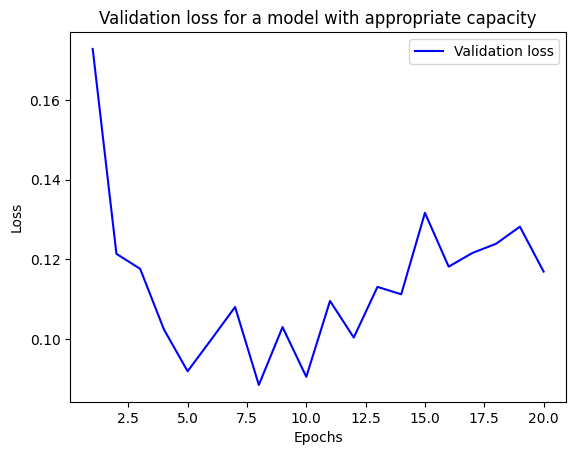

In [ ]:
val_loss = history_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with appropriate capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


# overfitted
# however loss is smaller -> better model

In [ ]:
# 2048개의 유닛을 가진 3개의 중간층으로 구성된 모델
model = keras.Sequential(
    [
        layers.Dense(2048, activation="relu"),   # ever larger model
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_very_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
)
# 과도한 모델 용량 -> 모델이 곧바로 과대적합

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9276 - loss: 0.2517 - val_accuracy: 0.9653 - val_loss: 0.1222
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9702 - loss: 0.1153 - val_accuracy: 0.9688 - val_loss: 0.1295
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9780 - loss: 0.0827 - val_accuracy: 0.9720 - val_loss: 0.1478
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9839 - loss: 0.0684 - val_accuracy: 0.9722 - val_loss: 0.1288
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9863 - loss: 0.0564 - val_accuracy: 0.9724 - val_loss: 0.1451
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9884 - loss: 0.0491 - val_accuracy: 0.9771 - val_loss: 0.1397
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9915 - loss: 0.0375 - val_accuracy: 0.9753 - val_loss: 0.1440
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9934 - loss: 0.0308 - 

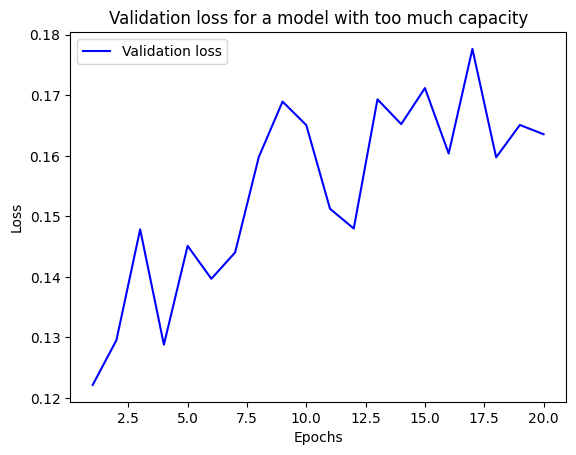

In [ ]:
val_loss = history_very_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with too much capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

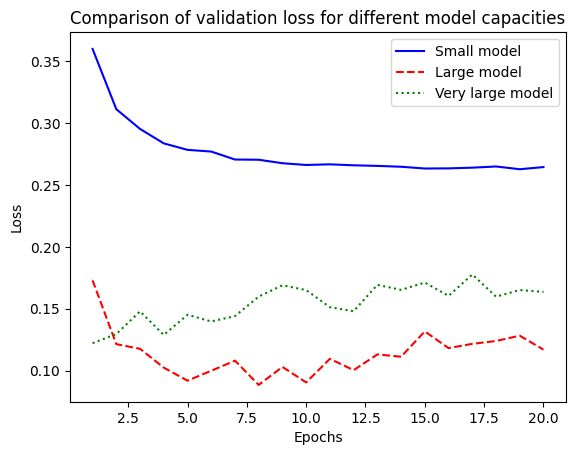

In [ ]:
epochs = range(1, 21)
plt.plot(
    epochs,
    history_small_model.history["val_loss"],
    "b-",
    label="Small model",
)
plt.plot(
    epochs,
    history_large_model.history["val_loss"],
    "r--",
    label="Large model",
)
plt.plot(
    epochs,
    history_very_large_model.history["val_loss"],
    "g:",
    label="Very large model",
)
plt.title("Comparison of validation loss for different model capacities")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Improving generalization

#### Dataset curation

#### Feature engineering

#### Using early stopping

#### Regularizing your model

##### Reducing the network's size

In [ ]:
from keras.datasets import imdb

(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

train_data = vectorize_sequences(train_data)   # preprocess our dataset

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_original = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)   # original model training

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.7756 - loss: 0.5024 - val_accuracy: 0.8427 - val_loss: 0.3941
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8977 - loss: 0.3015 - val_accuracy: 0.8845 - val_loss: 0.3042
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9232 - loss: 0.2274 - val_accuracy: 0.8815 - val_loss: 0.2914
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9397 - loss: 0.1816 - val_accuracy: 0.8889 - val_loss: 0.2769
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9531 - loss: 0.1464 - val_accuracy: 0.8814 - val_loss: 0.2941
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9573 - loss: 0.1300 - val_accuracy: 0.8838 - val_loss: 0.2956
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9641 - loss: 0.1118 - val_accuracy: 0.8814 - val_loss: 0.3201
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9743 - loss: 0.0927 - val_accuracy: 0.8822 - v

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(4, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_smaller_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)   # smaller model

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7358 - loss: 0.6242 - val_accuracy: 0.8393 - val_loss: 0.5581
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8556 - loss: 0.5002 - val_accuracy: 0.8609 - val_loss: 0.4606
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8845 - loss: 0.4066 - val_accuracy: 0.8711 - val_loss: 0.3962
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9003 - loss: 0.3385 - val_accuracy: 0.8786 - val_loss: 0.3465
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9108 - loss: 0.2879 - val_accuracy: 0.8832 - val_loss: 0.3155
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9210 - loss: 0.2507 - val_accuracy: 0.8875 - val_loss: 0.2964
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9295 - loss: 0.2227 - val_accuracy: 0.8872 - val_loss: 0.2862
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9361 - loss: 0.1992 - val_accuracy: 0.8908 - v

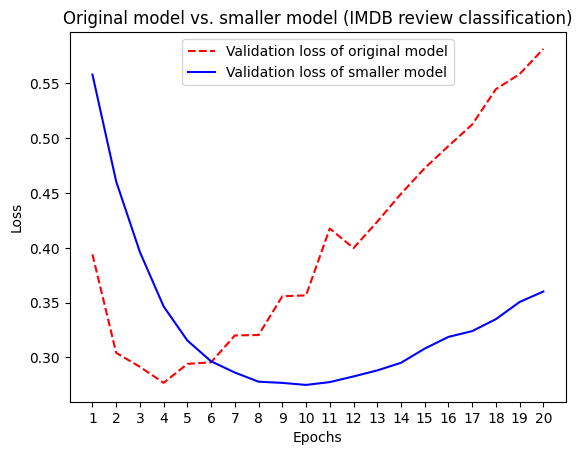

In [ ]:
original_val_loss = history_original.history["val_loss"]
smaller_model_val_loss = history_smaller_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    smaller_model_val_loss,
    "b-",
    label="Validation loss of smaller model",
)
plt.title("Original model vs. smaller model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_larger_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)   # larger model
# 용량이 많은 모델일수록 더 빠르게 훈련데이터를 모델링할 수 있지만 더욱 과대적합에 민감해진다
# 결국 훈련돠 검증 손실 사이에 큰 차이가 발생

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.7307 - loss: 0.5618 - val_accuracy: 0.7754 - val_loss: 0.4661
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8695 - loss: 0.3152 - val_accuracy: 0.8835 - val_loss: 0.2817
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9055 - loss: 0.2380 - val_accuracy: 0.8869 - val_loss: 0.2743
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9273 - loss: 0.1849 - val_accuracy: 0.8811 - val_loss: 0.3011
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9422 - loss: 0.1504 - val_accuracy: 0.8882 - val_loss: 0.2963
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9649 - loss: 0.1029 - val_accuracy: 0.8798 - val_loss: 0.3392
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9716 - loss: 0.0872 - val_accuracy: 0.8812 - val_loss: 0.3734
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9759 - loss: 0.0772 - val_accuracy: 0.8835 - v

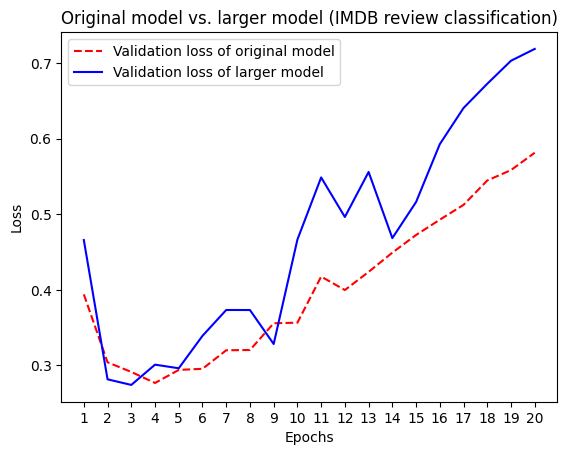

In [ ]:
original_val_loss = history_original.history["val_loss"]
larger_model_val_loss = history_larger_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    larger_model_val_loss,
    "b-",
    label="Validation loss of larger model",
)
plt.title("Original model vs. larger model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

##### Adding weight regularization

In [ ]:
from keras.regularizers import l2

model = keras.Sequential(
    [
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)   # ㅣ2(0.002): 가중치 행렬의 모든 원소를 제곱하고 0.002를 곱해 전체 손실에 더한다 (이 페널티항(손실 함수에 추가로 더해지는 규제)은 훈련할 때만 추가)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_l2_reg = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.7668 - loss: 0.6360 - val_accuracy: 0.8646 - val_loss: 0.5032
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8838 - loss: 0.4337 - val_accuracy: 0.8827 - val_loss: 0.4067
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9093 - loss: 0.3511 - val_accuracy: 0.8837 - val_loss: 0.3759
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9257 - loss: 0.3066 - val_accuracy: 0.8814 - val_loss: 0.3709
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9305 - loss: 0.2821 - val_accuracy: 0.8861 - val_loss: 0.3594
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9338 - loss: 0.2681 - val_accuracy: 0.8848 - val_loss: 0.3611
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9422 - loss: 0.2534 - val_accuracy: 0.8708 - val_loss: 0.3905
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9415 - loss: 0.2505 - val_accuracy: 0.8834 - v

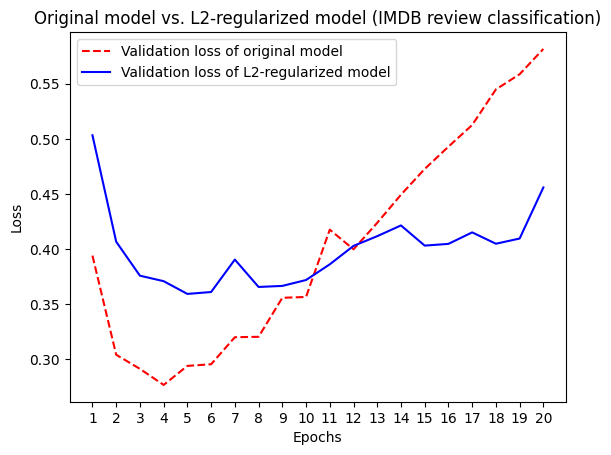

In [ ]:
original_val_loss = history_original.history["val_loss"]
l2_val_loss = history_l2_reg.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    l2_val_loss,
    "b-",
    label="Validation loss of L2-regularized model",
)
plt.title(
    "Original model vs. L2-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [ ]:
from keras import regularizers

regularizers.l1(0.001)   # l1 규제
regularizers.l1_l2(l1=0.001, l2=0.001)   # l1규제와 l2 규제 병행
# 가중치 규제는 일반적으로 작은 딥러닝 모델에서 사용
# 대규모 딥러닝 모델은 파라미터가 너무 많기 때문에 가중치 값을 제약하는 것이 모델 용량과 일반화에 큰 영향을 미치지 않는 경향이 있다
# 이런 경우 드롭아웃이라는 다른 규제방법이 선호된다

##### Adding dropout

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),   # add dropout layer -> 앞의 layer에 대해 dropout(무작위로 층의 출력 특성 일부를 제외시킨다(0으로 만든다))
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),   # 드롭아웃 비율은 0이 될 특성의 비율 (보통 0.2에서 0.5 사이로 지정)
        layers.Dense(1, activation="sigmoid"),
    ]
)   # 테스트 단계에서는 어떤 유닛도 드롭아웃 되지 않는다. 대신에 층의 출력을 드롭아웃 비율에 비례하여 줄여준다
# 드롭아웃은 층의 출력 값에 노이즈를 추가하여 중요하지 않은 우연한 패턴을 깨뜨리는 것
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.6517 - loss: 0.6247 - val_accuracy: 0.8490 - val_loss: 0.4977
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7669 - loss: 0.5052 - val_accuracy: 0.8707 - val_loss: 0.4052
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8163 - loss: 0.4329 - val_accuracy: 0.8784 - val_loss: 0.3473
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8418 - loss: 0.3867 - val_accuracy: 0.8882 - val_loss: 0.3129
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8682 - loss: 0.3425 - val_accuracy: 0.8881 - val_loss: 0.2947
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8846 - loss: 0.3053 - val_accuracy: 0.8847 - val_loss: 0.2849
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8999 - loss: 0.2703 - val_accuracy: 0.8918 - val_loss: 0.2792
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9087 - loss: 0.2485 - val_accuracy: 0.8880 - v

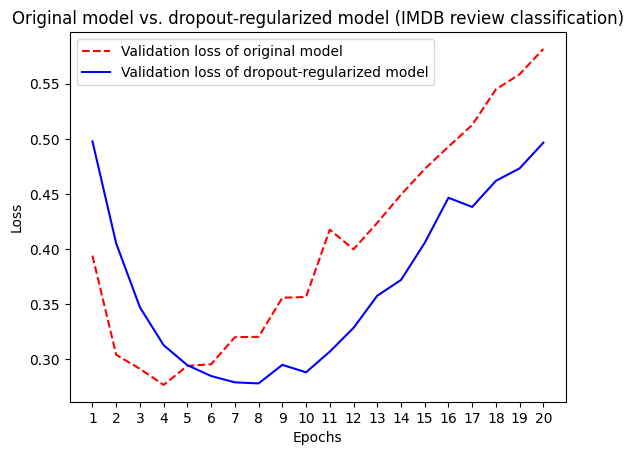

In [ ]:
original_val_loss = history_original.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    dropout_val_loss,
    "b-",
    label="Validation loss of dropout-regularized model",
)
plt.title(
    "Original model vs. dropout-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

Some questions

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout1 = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

In [ ]:
dropout1_val_loss = history_dropout1.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    dropout_val_loss,
    "g:",
    label="Validation loss of custom regularized model",
)

In [ ]:
# From Tuning key gradient descent parameters, Modify learning rates and check when model fails

In [ ]:
# Without hidden Dense layers it is exactly a (multi class) logistic regression, try this, study logistic regression on mnist data

In [ ]:
# Try with one hot encoded labels

In [ ]:
model = keras.Sequential(
    [
#        layers.Dense(512, relu)
        layers.Dense(10, activation="softmax")
    ]
)